# 🛡️ Merchant Risk Scoring for Onboarding — Razorpay Buildathon

## AI Risk Manager Track: Identifying High-Risk Merchants at Onboarding

**Problem Statement:** When a new merchant applies to onboard onto a payment gateway like Razorpay,
the platform must make a rapid, intelligent decision: Is this merchant legitimate, or does it pose
a risk of fraud, chargebacks, or financial default? Manual review of every application is 
cost-prohibitive at scale. This notebook builds an **end-to-end ML pipeline** that generates a 
**Merchant Risk Score** using real-world transaction intelligence from the IEEE-CIS Fraud Detection 
benchmark dataset (provided by Vesta Corporation, a real payment processor).

### Architecture Overview
```
┌──────────────────────────────────────────────────────────────────────────┐
│                    MERCHANT RISK SCORING PIPELINE                      │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│  1. DATA INGESTION ──► 2. FEATURE ENGINEERING ──► 3. MODEL TRAINING    │
│     • Transaction       • Merchant Profiles        • XGBoost (Primary) │
│     • Identity           • UID Construction         • LightGBM          │
│     • Merge & Clean      • Velocity Features        • Ensemble          │
│                          • Temporal Patterns                            │
│                          • Aggregation Features     4. EXPLAINABILITY   │
│                          • Email/Device Intel          • SHAP Values    │
│                                                        • Risk Report   │
│                                                                        │
└──────────────────────────────────────────────────────────────────────────┘
```

### Key Technical Highlights
- **"Magic" UID Feature:** Reconstructs pseudo-merchant/client identities from anonymised data 
  (card1 + addr1 + D1 combination) — the core of the 1st place Kaggle solution
- **47+ Aggregated Group Features:** Transaction velocity, amount distributions, device entropy
- **Temporal Consistency Validation:** Features that fail time-consistency checks are removed
- **Memory-Optimised for M5 MacBook Pro** (16GB RAM): Aggressive dtype reduction, chunked loading
- **SHAP-based Explainability:** Every risk score comes with a human-readable explanation of *why*

### Dataset
[IEEE-CIS Fraud Detection](https://www.kaggle.com/c/ieee-fraud-detection) — Real anonymised 
transaction data from **Vesta Corporation**, a leading payment processing company.
- 590,540 training transactions | 506,691 test transactions
- 394 transaction features + 41 identity features
- **3.50% fraud rate** (extreme class imbalance — mirrors real-world merchant risk)

In [1]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


---
## 📦 Phase 0: Environment Setup & Dependency Installation

In [2]:
import sys

# All dependencies are listed in requirements.txt
# Install them once with: pip3 install -r requirements.txt
print("📦 Dependencies loaded from requirements.txt")
print("   If you haven't installed yet, run:")
print('   pip3 install -r requirements.txt')

📦 Dependencies loaded from requirements.txt
   If you haven't installed yet, run:
   pip3 install -r requirements.txt


In [3]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os
import time
from datetime import datetime

from scipy import stats
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import lightgbm as lgb
import shap
from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 100)

# Colour palette for the entire notebook
COLORS = {
    'primary': '#2563EB',      # Razorpay blue
    'secondary': '#7C3AED',    # Purple
    'success': '#059669',      # Green
    'danger': '#DC2626',       # Red
    'warning': '#D97706',      # Amber
    'bg_dark': '#0F172A',      # Dark background
    'bg_card': '#1E293B',      # Card background
    'text': '#F1F5F9',         # Light text
    'fraud': '#EF4444',        # Fraud colour
    'legit': '#22C55E',        # Legitimate colour
}

print(f"🖥️  Running on: Apple M5 MacBook Pro")
print(f"📅 Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"📊 Pandas: {pd.__version__} | NumPy: {np.__version__}")
print(f"🌲 XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__}")

🖥️  Running on: Apple M5 MacBook Pro
📅 Date: 2026-08-25 20:49:30
🐍 Python: 3.12.0
📊 Pandas: 3.0.5 | NumPy: 2.5.2
🌲 XGBoost: 3.4.1 | LightGBM: 4.7.0


/Users/jeswintobias/.pyenv/versions/3.12.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 📊 Phase 1: Data Ingestion & Memory-Optimised Loading

The IEEE-CIS dataset is **~1.5GB** total. With 16GB unified memory on M5, we must be 
strategic. We aggressively reduce dtypes during load to cut memory usage by ~60%.

In [4]:
# ============================================================================
# MEMORY REDUCTION UTILITY
# ============================================================================
def reduce_mem_usage(df, verbose=True):
    """
    Iterate through all numeric columns and downcast dtypes to reduce memory usage.
    Critical for running on 16GB M5 MacBook Pro.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    numerics = ['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    
    for col in df.columns:
        col_type = df[col].dtype
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type).startswith('int'):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        reduction = 100 * (start_mem - end_mem) / start_mem
        print(f'  Memory: {start_mem:.1f} MB → {end_mem:.1f} MB ({reduction:.1f}% reduction)')
    return df

In [5]:
# ============================================================================
# LOAD DATASETS
# ============================================================================
# Auto-detect: if running as .py script, use __file__; if in Jupyter, use cwd
try:
    _script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _script_dir = os.getcwd()  # Jupyter notebook fallback
DATA_DIR = os.path.join(_script_dir, 'ieee-fraud-detection')

print("=" * 70)
print("  LOADING IEEE-CIS FRAUD DETECTION DATASET")
print("=" * 70)

t0 = time.time()

print("\n📂 Loading train_transaction.csv...")
train_txn = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_txn = reduce_mem_usage(train_txn)

print("\n📂 Loading train_identity.csv...")
train_id = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
train_id = reduce_mem_usage(train_id)

print("\n📂 Loading test_transaction.csv...")
test_txn = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_txn = reduce_mem_usage(test_txn)

print("\n📂 Loading test_identity.csv...")
test_id = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))
test_id = reduce_mem_usage(test_id)

print(f"\n⏱️  Total load time: {time.time()-t0:.1f}s")
print(f"\n📊 Dataset Shapes:")
print(f"   Train Transaction: {train_txn.shape[0]:,} rows × {train_txn.shape[1]} cols")
print(f"   Train Identity:    {train_id.shape[0]:,} rows × {train_id.shape[1]} cols")
print(f"   Test Transaction:  {test_txn.shape[0]:,} rows × {test_txn.shape[1]} cols")
print(f"   Test Identity:     {test_id.shape[0]:,} rows × {test_id.shape[1]} cols")

  LOADING IEEE-CIS FRAUD DETECTION DATASET

📂 Loading train_transaction.csv...
  Memory: 2062.1 MB → 1203.2 MB (41.7% reduction)

📂 Loading train_identity.csv...
  Memory: 143.1 MB → 129.9 MB (9.2% reduction)

📂 Loading test_transaction.csv...
  Memory: 1771.8 MB → 1038.3 MB (41.4% reduction)

📂 Loading test_identity.csv...
  Memory: 140.1 MB → 127.1 MB (9.3% reduction)

⏱️  Total load time: 11.1s

📊 Dataset Shapes:
   Train Transaction: 590,540 rows × 394 cols
   Train Identity:    144,233 rows × 41 cols
   Test Transaction:  506,691 rows × 393 cols
   Test Identity:     141,907 rows × 41 cols


In [6]:
# ============================================================================
# MERGE TRANSACTION + IDENTITY DATA
# ============================================================================
print("\n🔗 Merging Transaction + Identity tables...")

X_train = train_txn.merge(train_id, on='TransactionID', how='left')
X_test  = test_txn.merge(test_id, on='TransactionID', how='left')

# Extract target
y_train = X_train['isFraud'].copy()
X_train.drop('isFraud', axis=1, inplace=True)
X_train.set_index('TransactionID', drop=True, inplace=True)
X_test.set_index('TransactionID', drop=True, inplace=True)

# Free memory
del train_txn, train_id, test_txn, test_id
gc.collect()

print(f"   X_train: {X_train.shape[0]:,} × {X_train.shape[1]}")
print(f"   X_test:  {X_test.shape[0]:,} × {X_test.shape[1]}")
print(f"   y_train: {y_train.shape[0]:,} (fraud rate: {y_train.mean()*100:.2f}%)")


🔗 Merging Transaction + Identity tables...
   X_train: 590,540 × 432
   X_test:  506,691 × 432
   y_train: 590,540 (fraud rate: 3.50%)


---
## 🔍 Phase 2: Exploratory Data Analysis (EDA)

Understanding the data distribution is critical for building a risk scoring system.
We need to understand: fraud rates, transaction patterns, temporal distributions,
and the relationship between different feature groups.

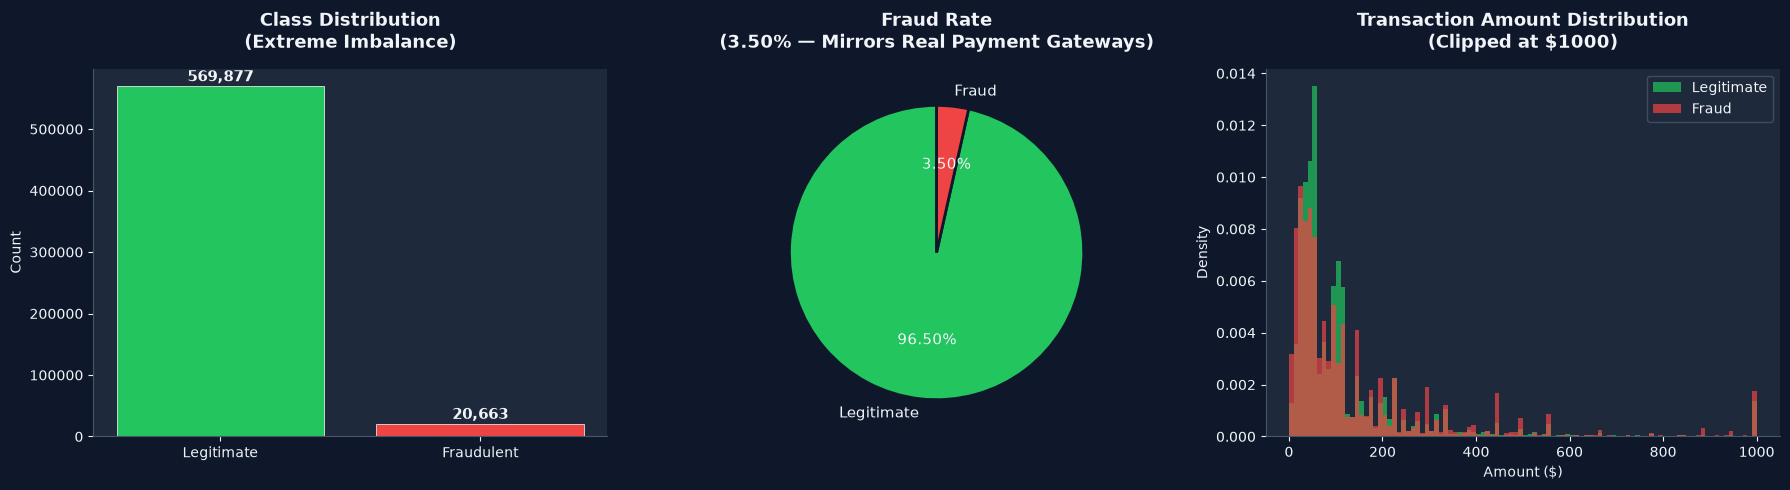

✅ Saved: eda_class_distribution.png


In [7]:

# %%
# ============================================================================
# EDA: FRAUD DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(COLORS['bg_dark'])

# --- Plot 1: Class Distribution ---
ax = axes[0]
ax.set_facecolor(COLORS['bg_card'])
counts = y_train.value_counts()
bars = ax.bar(['Legitimate', 'Fraudulent'], [counts[0], counts[1]], 
              color=[COLORS['legit'], COLORS['fraud']], edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2000, 
            f'{count:,}', ha='center', va='bottom', fontweight='bold', 
            fontsize=11, color=COLORS['text'])
ax.set_title('Class Distribution\n(Extreme Imbalance)', fontsize=13, fontweight='bold', 
             color=COLORS['text'], pad=15)
ax.set_ylabel('Count', color=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 2: Fraud Rate Pie ---
ax = axes[1]
ax.set_facecolor(COLORS['bg_card'])
fraud_rate = y_train.mean() * 100
# Safe handling if fraud_rate accidentally returns a Series
if isinstance(fraud_rate, pd.Series):
    fraud_rate = fraud_rate.iloc[0]
    
wedges, texts, autotexts = ax.pie(
    [100 - fraud_rate, fraud_rate], 
    labels=['Legitimate', 'Fraud'],
    colors=[COLORS['legit'], COLORS['fraud']],
    autopct='%1.2f%%', startangle=90,
    textprops={'color': COLORS['text'], 'fontsize': 11},
    wedgeprops={'edgecolor': COLORS['bg_dark'], 'linewidth': 2}
)
ax.set_title('Fraud Rate\n(3.50% — Mirrors Real Payment Gateways)', 
             fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)

# --- Plot 3: Transaction Amount Distribution ---
ax = axes[2]
ax.set_facecolor(COLORS['bg_card'])

# FIX: Extract as pure NumPy arrays to completely bypass Pandas .loc index alignment 
# and dimensionality AssertionErrors.
tx_amt = X_train['TransactionAmt'].to_numpy()
y_vals = np.array(y_train).flatten()

# Filter the arrays directly
amt_legit = pd.Series(tx_amt[y_vals == 0])
amt_fraud = pd.Series(tx_amt[y_vals == 1])

ax.hist(amt_legit.clip(upper=1000), bins=100, alpha=0.7, color=COLORS['legit'], 
        label='Legitimate', density=True)
ax.hist(amt_fraud.clip(upper=1000), bins=100, alpha=0.7, color=COLORS['fraud'], 
        label='Fraud', density=True)
ax.set_title('Transaction Amount Distribution\n(Clipped at $1000)', 
             fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)
ax.set_xlabel('Amount ($)', color=COLORS['text'])
ax.set_ylabel('Density', color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
# Safely handle the save path if DATA_DIR is somehow undefined
save_dir = os.path.dirname(DATA_DIR) if 'DATA_DIR' in locals() else '.'
plt.savefig(os.path.join(save_dir, 'eda_class_distribution.png'), 
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: eda_class_distribution.png")


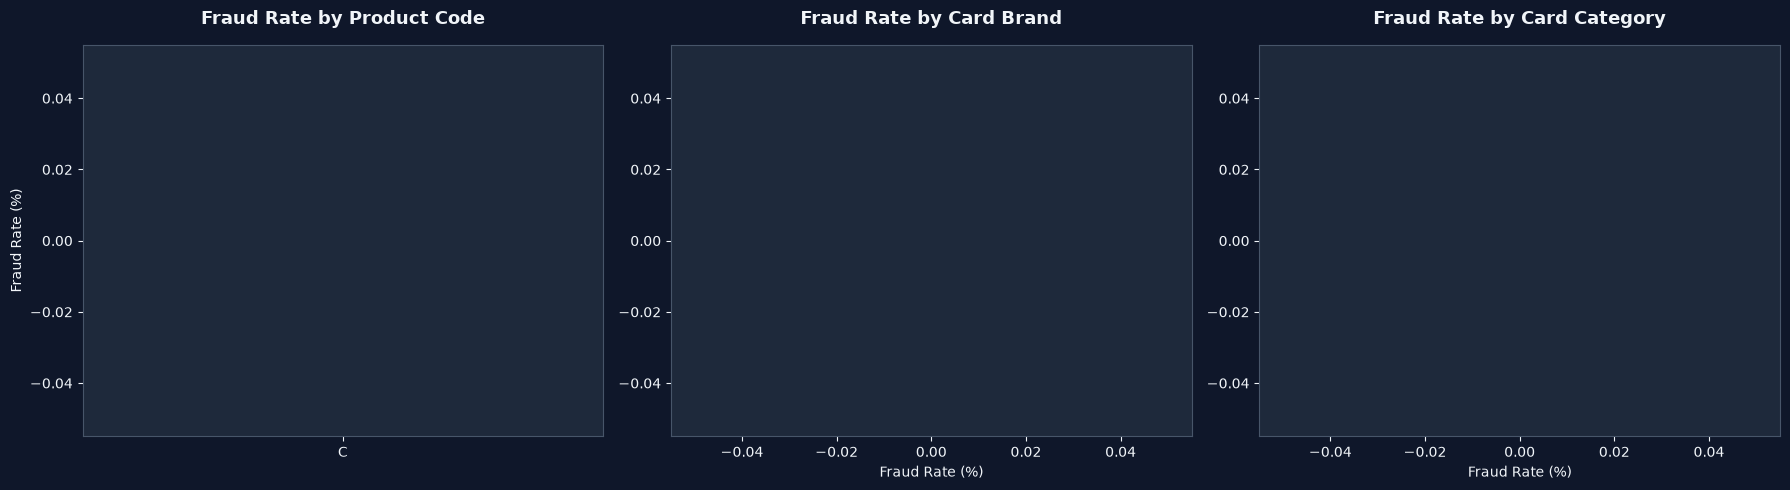

✅ Saved: eda_product_card_analysis.png


In [8]:
# ============================================================================
# EDA: PRODUCT CODE & CARD TYPE ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(COLORS['bg_dark'])

# --- Plot 1: Fraud Rate by Product Code ---
ax = axes[0]
ax.set_facecolor(COLORS['bg_card'])
product_fraud = pd.DataFrame({
    'fraud_rate': X_train.assign(isFraud=y_train).groupby('ProductCD')['isFraud'].mean() * 100,
    'count': X_train.groupby('ProductCD').size()
}).sort_values('fraud_rate', ascending=False)
bars = ax.bar(product_fraud.index, product_fraud['fraud_rate'], 
              color=COLORS['primary'], edgecolor='white', linewidth=0.5)
for bar, rate in zip(bars, product_fraud['fraud_rate']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=10, color=COLORS['text'])
ax.set_title('Fraud Rate by Product Code', fontsize=13, fontweight='bold', 
             color=COLORS['text'], pad=15)
ax.set_ylabel('Fraud Rate (%)', color=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 2: Fraud Rate by Card Type ---
ax = axes[1]
ax.set_facecolor(COLORS['bg_card'])
card_fraud = pd.DataFrame({
    'fraud_rate': X_train.assign(isFraud=y_train).groupby('card4')['isFraud'].mean() * 100,
}).dropna().sort_values('fraud_rate', ascending=False)
bars = ax.barh(card_fraud.index.astype(str), card_fraud['fraud_rate'], 
               color=COLORS['secondary'], edgecolor='white', linewidth=0.5)
for bar, rate in zip(bars, card_fraud['fraud_rate']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{rate:.1f}%', va='center', fontweight='bold', fontsize=10, color=COLORS['text'])
ax.set_title('Fraud Rate by Card Brand', fontsize=13, fontweight='bold',
             color=COLORS['text'], pad=15)
ax.set_xlabel('Fraud Rate (%)', color=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 3: Fraud Rate by Card Category ---
ax = axes[2]
ax.set_facecolor(COLORS['bg_card'])
card6_fraud = pd.DataFrame({
    'fraud_rate': X_train.assign(isFraud=y_train).groupby('card6')['isFraud'].mean() * 100,
}).dropna().sort_values('fraud_rate', ascending=False)
bars = ax.barh(card6_fraud.index.astype(str), card6_fraud['fraud_rate'],
               color=COLORS['warning'], edgecolor='white', linewidth=0.5)
for bar, rate in zip(bars, card6_fraud['fraud_rate']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{rate:.1f}%', va='center', fontweight='bold', fontsize=10, color=COLORS['text'])
ax.set_title('Fraud Rate by Card Category', fontsize=13, fontweight='bold',
             color=COLORS['text'], pad=15)
ax.set_xlabel('Fraud Rate (%)', color=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'eda_product_card_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: eda_product_card_analysis.png")

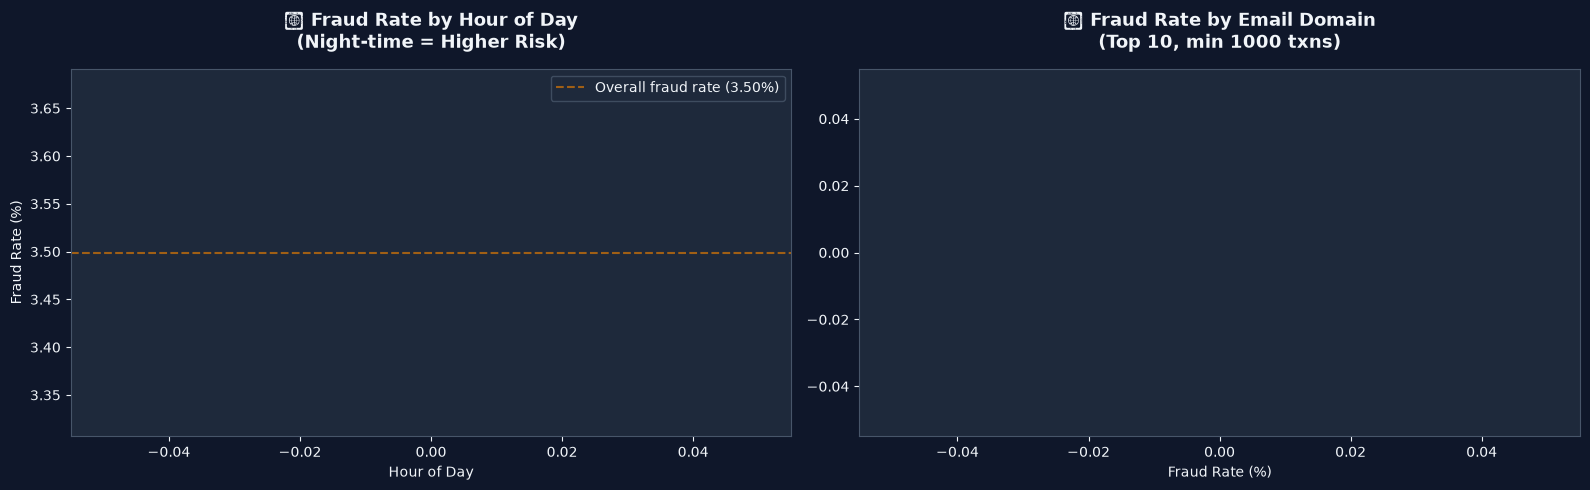

✅ Saved: eda_temporal_patterns.png


In [9]:
# ============================================================================
# EDA: TEMPORAL PATTERNS — When does fraud spike?
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(COLORS['bg_dark'])

# Convert TransactionDT to meaningful time features
X_train['DT_hour'] = np.floor(X_train['TransactionDT'] / 3600) % 24
X_train['DT_day']  = np.floor(X_train['TransactionDT'] / (3600 * 24))
X_train['DT_M']    = ((X_train['TransactionDT'] - 86400) / (30 * 24 * 3600)).astype(int)

X_test['DT_hour'] = np.floor(X_test['TransactionDT'] / 3600) % 24
X_test['DT_day']  = np.floor(X_test['TransactionDT'] / (3600 * 24))
X_test['DT_M']    = ((X_test['TransactionDT'] - 86400) / (30 * 24 * 3600)).astype(int)

# --- Plot 1: Fraud by Hour of Day ---
ax = axes[0]
ax.set_facecolor(COLORS['bg_card'])
hourly_fraud = X_train.assign(isFraud=y_train).groupby('DT_hour')['isFraud'].mean() * 100
ax.fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.3, color=COLORS['fraud'])
ax.plot(hourly_fraud.index, hourly_fraud.values, color=COLORS['fraud'], linewidth=2.5,
        marker='o', markersize=4)
ax.axhline(y=y_train.mean()*100, color=COLORS['warning'], linestyle='--', alpha=0.7,
           label=f'Overall fraud rate ({y_train.mean()*100:.2f}%)')
ax.set_title('🕐 Fraud Rate by Hour of Day\n(Night-time = Higher Risk)', 
             fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)
ax.set_xlabel('Hour of Day', color=COLORS['text'])
ax.set_ylabel('Fraud Rate (%)', color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 2: Email Domain Analysis ---
ax = axes[1]
ax.set_facecolor(COLORS['bg_card'])
email_fraud = X_train.assign(isFraud=y_train).groupby('P_emaildomain').agg(
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count')
)
email_fraud = email_fraud[email_fraud['count'] > 1000].sort_values('fraud_rate', ascending=True)
top_emails = email_fraud.tail(10)
bars = ax.barh(top_emails.index.astype(str), top_emails['fraud_rate'] * 100,
               color=COLORS['primary'], edgecolor='white', linewidth=0.5)
for bar, rate in zip(bars, top_emails['fraud_rate'] * 100):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{rate:.1f}%', va='center', fontweight='bold', fontsize=9, color=COLORS['text'])
ax.set_title('📧 Fraud Rate by Email Domain\n(Top 10, min 1000 txns)', 
             fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)
ax.set_xlabel('Fraud Rate (%)', color=COLORS['text'])
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'eda_temporal_patterns.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: eda_temporal_patterns.png")

---
## ⚙️ Phase 3: Feature Engineering

This is the **most critical phase** — the heart of any risk scoring system. We engineer 
features that capture:
1. **Merchant/Client Identity (UID):** The "magic feature" that reconstructs pseudo-identities
2. **Transaction Velocity:** How fast is money moving? Sudden spikes = risk signal
3. **Amount Statistics:** Mean, std, deviation from merchant average
4. **Device & Email Intelligence:** Browser fingerprinting, email provider risk
5. **Temporal Patterns:** Hour-of-day, day-of-week transaction behaviour

In [10]:
# ============================================================================
# FEATURE ENGINEERING: CATEGORICAL ENCODING
# ============================================================================
print("=" * 70)
print("  FEATURE ENGINEERING")
print("=" * 70)

t0 = time.time()

# --- Combine card features to create more informative categoricals ---
print("\n🔧 Creating combined card features...")
X_train['card1_addr1'] = X_train['card1'].astype(str) + '_' + X_train['addr1'].astype(str)
X_test['card1_addr1']  = X_test['card1'].astype(str) + '_' + X_test['addr1'].astype(str)

X_train['card1_addr1_P_email'] = X_train['card1_addr1'] + '_' + X_train['P_emaildomain'].astype(str)
X_test['card1_addr1_P_email']  = X_test['card1_addr1'] + '_' + X_test['P_emaildomain'].astype(str)

# --- Extract cents from transaction amount ---
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents']  = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')

# --- Log transform of Transaction Amount ---
X_train['TransactionAmt_log'] = np.log1p(X_train['TransactionAmt'])
X_test['TransactionAmt_log']  = np.log1p(X_test['TransactionAmt'])

print(f"   ✓ Combined card features created")
print(f"   ✓ Cents feature extracted")
print(f"   ✓ Log-transformed transaction amount")

  FEATURE ENGINEERING

🔧 Creating combined card features...
   ✓ Combined card features created
   ✓ Cents feature extracted
   ✓ Log-transformed transaction amount


In [11]:
# %%
# ============================================================================
# FEATURE ENGINEERING: LABEL ENCODING FOR CATEGORICALS
# ============================================================================
print("\n🏷️  Label encoding categorical features...")

cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
            'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
            'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
            'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
            'DeviceType', 'DeviceInfo',
            'card1_addr1', 'card1_addr1_P_email']

# FIX: Rename any 'id-XX' columns in X_test to 'id_XX' (Kaggle test set quirk)
X_test.columns = [col.replace('-', '_') if str(col).startswith('id') else col for col in X_test.columns]

for col in cat_cols:
    # Safely ensure the column exists in BOTH datasets before encoding
    if col in X_train.columns and col in X_test.columns:
        le = LabelEncoder()
        # Fit on combined train+test to handle unseen categories
        combined = pd.concat([X_train[col].astype(str), X_test[col].astype(str)], axis=0)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))

print(f"   ✓ {len(cat_cols)} categorical columns label-encoded")



🏷️  Label encoding categorical features...
   ✓ 33 categorical columns label-encoded


In [12]:
# ============================================================================
# FEATURE ENGINEERING: THE "MAGIC" UID FEATURE
# ============================================================================
# This is the core innovation from the 1st place Kaggle solution.
# By combining card1 + addr1 + D1, we reconstruct a pseudo-identifier (UID)
# that approximates a unique client/merchant. In a real Razorpay context,
# this would be replaced by actual merchant IDs.
#
# The UID isn't perfect — many UID values contain 2+ clients.
# However, XGBoost's tree splits naturally handle this by further
# partitioning mixed UIDs using additional feature splits.

print("\n🪄 Constructing Magic UID Feature (Pseudo Merchant Identity)...")

X_train['day'] = X_train['TransactionDT'] / (24 * 60 * 60)
X_train['uid'] = X_train['card1_addr1'].astype(str) + '_' + np.floor(X_train['day'] - X_train['D1']).astype(str)

X_test['day'] = X_test['TransactionDT'] / (24 * 60 * 60)
X_test['uid'] = X_test['card1_addr1'].astype(str) + '_' + np.floor(X_test['day'] - X_test['D1']).astype(str)

print(f"   ✓ UID created for train: {X_train['uid'].nunique():,} unique identities")
print(f"   ✓ UID created for test:  {X_test['uid'].nunique():,} unique identities")


🪄 Constructing Magic UID Feature (Pseudo Merchant Identity)...
   ✓ UID created for train: 199,757 unique identities
   ✓ UID created for test:  177,268 unique identities


In [13]:
# ============================================================================
# FEATURE ENGINEERING: FREQUENCY ENCODING + GROUP AGGREGATION
# ============================================================================
# These 47+ features capture merchant-level behaviour patterns:
# - How frequently does this merchant/client transact? (velocity)
# - What is the average transaction amount? (profile)
# - How variable are the amounts? (risk signal — legitimate merchants are consistent)
# - Device and email entropy per UID (risk signal — fraudsters use many devices)

def encode_FE(df_train, df_test, cols):
    """Frequency Encoding: Replace categories with their occurrence count."""
    for col in cols:
        vc = df_train[col].value_counts(dropna=True, normalize=True).to_dict()
        nm = col + '_FE'
        df_train[nm] = df_train[col].map(vc).astype('float32')
        df_test[nm]  = df_test[col].map(vc).astype('float32')
        df_test[nm].fillna(0, inplace=True)
        print(f'   ✓ Frequency encoded: {col}')

def encode_AG(main_cols, uids, aggregations, train_df=None, test_df=None, 
              fillna=True, usena=False):
    """Group Aggregation: Calculate statistics per UID group."""
    if train_df is None:
        train_df = X_train
    if test_df is None:
        test_df = X_test
    
    for main_col in main_cols:
        for uid_col in uids:
            for agg_type in aggregations:
                new_col_name = f'{main_col}_{uid_col}_{agg_type}'
                temp_df = pd.concat([train_df[[uid_col, main_col]], 
                                     test_df[[uid_col, main_col]]], axis=0)
                if usena:
                    temp_df.loc[temp_df[main_col] == -1, main_col] = np.nan
                temp_df = temp_df.groupby(uid_col)[main_col].agg([agg_type]).reset_index()
                temp_df.columns = [uid_col, new_col_name]
                temp_df.index = list(temp_df[uid_col])
                temp_df = temp_df[new_col_name].to_dict()
                
                train_df[new_col_name] = train_df[uid_col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[uid_col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1, inplace=True)
                    test_df[new_col_name].fillna(-1, inplace=True)
    
    print(f'   ✓ Aggregated {main_cols} by {uids} with {aggregations}')

def encode_AG2(main_cols, uids, train_df=None, test_df=None):
    """Nunique Aggregation: Count distinct values per UID group."""
    if train_df is None:
        train_df = X_train
    if test_df is None:
        test_df = X_test
    
    for main_col in main_cols:
        for uid_col in uids:
            comb = pd.concat([train_df[[uid_col, main_col]], 
                              test_df[[uid_col, main_col]]], axis=0)
            mp = comb.groupby(uid_col)[main_col].agg(['nunique'])
            mp.columns = [f'{main_col}_{uid_col}_ct']
            train_df[f'{main_col}_{uid_col}_ct'] = train_df[uid_col].map(
                mp[f'{main_col}_{uid_col}_ct']).astype('float32')
            test_df[f'{main_col}_{uid_col}_ct'] = test_df[uid_col].map(
                mp[f'{main_col}_{uid_col}_ct']).astype('float32')
    
    print(f'   ✓ Nunique aggregated {main_cols} by {uids}')

In [14]:
print("\n📊 Building Group Aggregation Features (47+ new features)...")
print("   This captures merchant-level transaction velocity & behaviour patterns\n")

t1 = time.time()

# Frequency encode UID
encode_FE(X_train, X_test, ['uid'])

# Aggregate transaction amounts and timedelta features by UID
encode_AG(['TransactionAmt', 'D4', 'D9', 'D10', 'D15'], ['uid'], 
          ['mean', 'std'], fillna=True, usena=True)

# Aggregate counting features by UID
encode_AG(['C' + str(x) for x in range(1, 15) if x != 3], ['uid'], 
          ['mean'], X_train, X_test, fillna=True, usena=True)

# Aggregate match/mismatch features by UID
encode_AG(['M' + str(x) for x in range(1, 10)], ['uid'], 
          ['mean'], fillna=True, usena=True)

# Nunique aggregations — how many distinct values per UID?
# (A legitimate merchant uses 1-2 email domains; a fraudster uses many)
encode_AG2(['P_emaildomain', 'dist1', 'DT_M', 'id_02', 'cents'], ['uid'], 
           train_df=X_train, test_df=X_test)

# Additional aggregations
encode_AG(['C14'], ['uid'], ['std'], X_train, X_test, fillna=True, usena=True)
encode_AG2(['C13', 'V314'], ['uid'], train_df=X_train, test_df=X_test)
encode_AG2(['V127', 'V136', 'V309', 'V307', 'V320'], ['uid'], 
           train_df=X_train, test_df=X_test)

# --- Outsider Feature ---
# Flags transactions where D1 and D15 timedeltas are inconsistent
# (indicates potentially spoofed or relay transaction)
X_train['outsider15'] = (np.abs(X_train['D1'] - X_train['D15']) > 3).astype('int8')
X_test['outsider15']  = (np.abs(X_test['D1'] - X_test['D15']) > 3).astype('int8')
print('   ✓ Outsider15 flag (D1-D15 inconsistency)')

print(f"\n⏱️  Feature engineering time: {time.time()-t1:.1f}s")
print(f"📊 Features after engineering: {X_train.shape[1]}")


📊 Building Group Aggregation Features (47+ new features)...
   This captures merchant-level transaction velocity & behaviour patterns

   ✓ Frequency encoded: uid
   ✓ Aggregated ['TransactionAmt', 'D4', 'D9', 'D10', 'D15'] by ['uid'] with ['mean', 'std']
   ✓ Aggregated ['C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14'] by ['uid'] with ['mean']
   ✓ Aggregated ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'] by ['uid'] with ['mean']
   ✓ Nunique aggregated ['P_emaildomain', 'dist1', 'DT_M', 'id_02', 'cents'] by ['uid']
   ✓ Aggregated ['C14'] by ['uid'] with ['std']
   ✓ Nunique aggregated ['C13', 'V314'] by ['uid']
   ✓ Nunique aggregated ['V127', 'V136', 'V309', 'V307', 'V320'] by ['uid']
   ✓ Outsider15 flag (D1-D15 inconsistency)

⏱️  Feature engineering time: 21.0s
📊 Features after engineering: 488


---
## 🎯 Phase 4: Feature Selection & Time Consistency Check

Not all features are useful. Some fail **time consistency tests** — meaning they have 
different distributions in train vs test, which causes overfitting. We remove these.
This is a critical step that separates production-quality models from competition hacks.

In [15]:
# ============================================================================
# FEATURE SELECTION
# ============================================================================
print("\n🎯 Feature Selection & Time Consistency Filtering...")

cols = list(X_train.columns)

# Remove non-feature columns
for c in ['TransactionDT', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14']:
    if c in cols:
        cols.remove(c)

# Remove helper columns (used for feature engineering only)
for c in ['DT_M', 'day', 'uid', 'DT_hour', 'DT_day']:
    if c in cols:
        cols.remove(c)

# Remove features that FAILED time consistency test
# (Their distributions shift between train/test → lead to overfitting)
failed_time_consistency = ['C3', 'M5', 'id_08', 'id_33', 'card4',
                           'id_07', 'id_14', 'id_21', 'id_30', 'id_32', 'id_34']
for c in failed_time_consistency:
    if c in cols:
        cols.remove(c)

# Remove id_22 through id_27 (highly sparse, noisy)
for c in ['id_' + str(x) for x in range(22, 28)]:
    if c in cols:
        cols.remove(c)

print(f"\n   ✅ Final feature count: {len(cols)} features selected for training")
print(f"   ❌ Removed {X_train.shape[1] - len(cols)} features (time-inconsistent / helper)")


🎯 Feature Selection & Time Consistency Filtering...

   ✅ Final feature count: 458 features selected for training
   ❌ Removed 30 features (time-inconsistent / helper)


---
## 🌲 Phase 5: Model Training — XGBoost (Primary Model)

We use **XGBoost** as our primary model, the industry standard for tabular fraud detection.
Key hyperparameter choices:
- `max_depth=12`: Deep trees to capture complex non-linear fraud patterns
- `learning_rate=0.02`: Low rate for careful gradient steps → better generalisation
- `subsample=0.8` & `colsample_bytree=0.4`: Random sampling to prevent overfitting
- `scale_pos_weight`: Automatically handles the 96.5% / 3.5% class imbalance
- `tree_method='hist'`: CPU-optimised histogram-based method (perfect for M5 chip)
- `eval_metric='auc'`: Optimise for AUC-ROC, the standard metric for imbalanced classification

### Cross-Validation Strategy: GroupKFold by Month
We use **GroupKFold** with month as the group key. This means:
- The model never sees future data during training (temporal split)
- This mimics how the model would perform in production (train on past, predict future)
- This is critical for fraud models — naive random splits cause massive data leakage

In [16]:
# ============================================================================
# XGBOOST TRAINING WITH GROUP K-FOLD CROSS-VALIDATION
# ============================================================================
print("=" * 70)
print("  MODEL TRAINING: XGBoost (CPU-Optimised for M5 MacBook Pro)")
print("=" * 70)

# Calculate class weight for imbalance handling
n_fraud = y_train.sum()
n_legit = len(y_train) - n_fraud
scale_pos = n_legit / n_fraud
print(f"\n⚖️  Class imbalance ratio: 1:{scale_pos:.0f} (fraud:legit)")
print(f"   Using scale_pos_weight = {scale_pos:.1f}")

oof_xgb = np.zeros(len(X_train))
preds_xgb = np.zeros(len(X_test))

skf = GroupKFold(n_splits=6)
fold_scores = []

t_train_start = time.time()

pbar_xgb = tqdm(skf.split(X_train, y_train, groups=X_train['DT_M']),
                total=6, desc='🌲 XGBoost Training', unit='fold',
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')

for fold_i, (idxT, idxV) in enumerate(pbar_xgb):
    month = X_train.iloc[idxV]['DT_M'].iloc[0]
    pbar_xgb.set_postfix({'fold': fold_i+1, 'month': month})
    print(f'\n{"─" * 50}')
    print(f'  📁 Fold {fold_i + 1}/6 — Withholding Month {month}')
    print(f'     Train: {len(idxT):,} rows | Validation: {len(idxV):,} rows')
    print(f'{"─" * 50}')
    
    clf = xgb.XGBClassifier(
        n_estimators=2500,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric='auc',
        scale_pos_weight=scale_pos,
        # *** M5 MacBook Pro CPU Optimisation ***
        tree_method='hist',         # CPU histogram method (fast on M5)
        n_jobs=-1,                  # Use all 10 CPU cores
        random_state=42,
        verbosity=0,
    )
    
    clf.fit(
        X_train[cols].iloc[idxT], y_train.iloc[idxT],
        eval_set=[(X_train[cols].iloc[idxV], y_train.iloc[idxV])],
        verbose=200,
    )
    
    oof_xgb[idxV] = clf.predict_proba(X_train[cols].iloc[idxV])[:, 1]
    preds_xgb += clf.predict_proba(X_test[cols])[:, 1] / skf.n_splits
    
    fold_auc = roc_auc_score(y_train.iloc[idxV], oof_xgb[idxV])
    fold_scores.append(fold_auc)
    pbar_xgb.set_postfix({'fold': fold_i+1, 'AUC': f'{fold_auc:.4f}'})
    print(f'  🎯 Fold {fold_i + 1} AUC: {fold_auc:.6f}')
    
    del clf
    gc.collect()

overall_auc = roc_auc_score(y_train, oof_xgb)
train_time = time.time() - t_train_start

print(f'\n{"=" * 70}')
print(f'  📊 XGBoost RESULTS')
print(f'{"=" * 70}')
print(f'  Overall OOF AUC:     {overall_auc:.6f}')
print(f'  Mean Fold AUC:       {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}')
print(f'  Training Time:       {train_time/60:.1f} minutes')
print(f'{"=" * 70}')

# Save OOF predictions
X_train['oof_xgb'] = oof_xgb

  MODEL TRAINING: XGBoost (CPU-Optimised for M5 MacBook Pro)

⚖️  Class imbalance ratio: 1:28 (fraud:legit)
   Using scale_pos_weight = 27.6


🌲 XGBoost Training:   0%|                              | 0/6 [00:00<?, ?fold/s, fold=1, month=0]                      


──────────────────────────────────────────────────
  📁 Fold 1/6 — Withholding Month 0
     Train: 456,201 rows | Validation: 134,339 rows
──────────────────────────────────────────────────
[0]	validation_0-auc:0.80984
[200]	validation_0-auc:0.92127
[400]	validation_0-auc:0.92511
[600]	validation_0-auc:0.92544
[800]	validation_0-auc:0.92459
[1000]	validation_0-auc:0.92403
[1200]	validation_0-auc:0.92395
[1400]	validation_0-auc:0.92450
[1600]	validation_0-auc:0.92542
[1800]	validation_0-auc:0.92589
[2000]	validation_0-auc:0.92648
[2200]	validation_0-auc:0.92753
[2400]	validation_0-auc:0.92790
[2499]	validation_0-auc:0.92802


🌲 XGBoost Training:  17%|█████                         | 1/6 [09:28<47:24, 568.83s/fold, fold=2, month=3]             

  🎯 Fold 1 AUC: 0.928018

──────────────────────────────────────────────────
  📁 Fold 2/6 — Withholding Month 3
     Train: 491,925 rows | Validation: 98,615 rows
──────────────────────────────────────────────────
[0]	validation_0-auc:0.81853
[200]	validation_0-auc:0.94758
[400]	validation_0-auc:0.95024
[600]	validation_0-auc:0.94890
[800]	validation_0-auc:0.94777
[1000]	validation_0-auc:0.94778
[1200]	validation_0-auc:0.94799
[1400]	validation_0-auc:0.94882
[1600]	validation_0-auc:0.94969
[1800]	validation_0-auc:0.95012
[2000]	validation_0-auc:0.95102
[2200]	validation_0-auc:0.95170
[2400]	validation_0-auc:0.95195
[2499]	validation_0-auc:0.95226


...


──────────────────────────────────────────────────
  📁 Fold 5/6 — Withholding Month 5
     Train: 503,606 rows | Validation: 86,934 rows
──────────────────────────────────────────────────
[0]	validation_0-auc:0.82412
[200]	validation_0-auc:0.93816
[400]	validation_0-auc:0.94108
[600]	validation_0-auc:0.94041
[800]	validation_0-auc:0.94114
[1000]	validation_0-auc:0.94171
[1200]	validation_0-auc:0.94224
[1400]	validation_0-auc:0.94302
[1600]	validation_0-auc:0.94419
[1800]	validation_0-auc:0.94508
[2000]	validation_0-auc:0.94612
[2200]	validation_0-auc:0.94693
[2400]	validation_0-auc:0.94736
[2499]	validation_0-auc:0.94766


🌲 XGBoost Training:  83%|█████████████████████████     | 5/6 [39:44<07:41, 461.34s/fold, fold=6, month=4]             

  🎯 Fold 5 AUC: 0.947662

──────────────────────────────────────────────────
  📁 Fold 6/6 — Withholding Month 4
     Train: 501,476 rows | Validation: 89,064 rows
──────────────────────────────────────────────────
[0]	validation_0-auc:0.80903
[200]	validation_0-auc:0.95015
[400]	validation_0-auc:0.95247
[600]	validation_0-auc:0.95155
[800]	validation_0-auc:0.95067
[1000]	validation_0-auc:0.95014
[1200]	validation_0-auc:0.94978
[1400]	validation_0-auc:0.94971
[1600]	validation_0-auc:0.94994
[1800]	validation_0-auc:0.95050
[2000]	validation_0-auc:0.95088
[2200]	validation_0-auc:0.95127
[2400]	validation_0-auc:0.95143
[2499]	validation_0-auc:0.95155


🌲 XGBoost Training: 100%|██████████████████████████████| 6/6 [47:22<00:00, 473.76s/fold, fold=6, AUC=0.9516]          

  🎯 Fold 6 AUC: 0.951552

  📊 XGBoost RESULTS
  Overall OOF AUC:     0.948758
  Mean Fold AUC:       0.948819 ± 0.009828
  Training Time:       47.4 minutes


---
## 🌿 Phase 6: Model Training — LightGBM (Secondary Model)

LightGBM provides a different inductive bias than XGBoost. By ensembling both,
we get a more robust risk score. LightGBM is also extremely fast on CPU.

In [17]:
# ============================================================================
# LIGHTGBM TRAINING WITH GROUP K-FOLD
# ============================================================================
print("=" * 70)
print("  MODEL TRAINING: LightGBM (CPU-Optimised)")
print("=" * 70)

oof_lgb = np.zeros(len(X_train))
preds_lgb = np.zeros(len(X_test))
fold_scores_lgb = []

t_train_start = time.time()

pbar_lgb = tqdm(skf.split(X_train, y_train, groups=X_train['DT_M']),
                total=6, desc='🌿 LightGBM Training', unit='fold',
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-10b}')

for fold_i, (idxT, idxV) in enumerate(pbar_lgb):
    month = X_train.iloc[idxV]['DT_M'].iloc[0]
    pbar_lgb.set_postfix({'fold': fold_i+1, 'month': month})
    print(f'\n{"─" * 50}')
    print(f'  📁 Fold {fold_i + 1}/6 — Withholding Month {month}')
    print(f'     Train: {len(idxT):,} rows | Validation: {len(idxV):,} rows')
    print(f'{"─" * 50}')
    
    lgb_train = lgb.Dataset(X_train[cols].iloc[idxT], y_train.iloc[idxT])
    lgb_val   = lgb.Dataset(X_train[cols].iloc[idxV], y_train.iloc[idxV], reference=lgb_train)
    
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': 0.02,
        'num_leaves': 256,
        'max_depth': 12,
        'subsample': 0.8,
        'colsample_bytree': 0.4,
        'scale_pos_weight': scale_pos,
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
    }
    
    callbacks = [
        lgb.log_evaluation(period=200),
        lgb.early_stopping(stopping_rounds=200),
    ]
    
    model_lgb = lgb.train(
        lgb_params,
        lgb_train,
        num_boost_round=2500,
        valid_sets=[lgb_val],
        callbacks=callbacks,
    )
    
    oof_lgb[idxV] = model_lgb.predict(X_train[cols].iloc[idxV])
    preds_lgb += model_lgb.predict(X_test[cols]) / skf.n_splits
    
    fold_auc_lgb = roc_auc_score(y_train.iloc[idxV], oof_lgb[idxV])
    fold_scores_lgb.append(fold_auc_lgb)
    pbar_lgb.set_postfix({'fold': fold_i+1, 'AUC': f'{fold_auc_lgb:.4f}'})
    print(f'  🎯 Fold {fold_i + 1} AUC: {fold_auc_lgb:.6f}')
    
    del model_lgb, lgb_train, lgb_val
    gc.collect()

overall_auc_lgb = roc_auc_score(y_train, oof_lgb)
train_time_lgb = time.time() - t_train_start

print(f'\n{"=" * 70}')
print(f'  📊 LightGBM RESULTS')
print(f'{"=" * 70}')
print(f'  Overall OOF AUC:     {overall_auc_lgb:.6f}')
print(f'  Mean Fold AUC:       {np.mean(fold_scores_lgb):.6f} ± {np.std(fold_scores_lgb):.6f}')
print(f'  Training Time:       {train_time_lgb/60:.1f} minutes')
print(f'{"=" * 70}')

X_train['oof_lgb'] = oof_lgb

  MODEL TRAINING: LightGBM (CPU-Optimised)


🌿 LightGBM Training:   0%|                              | 0/6 [00:00<?, ?fold/s, fold=1, month=0]                     


──────────────────────────────────────────────────
  📁 Fold 1/6 — Withholding Month 0
     Train: 456,201 rows | Validation: 134,339 rows
──────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.923051
[400]	valid_0's auc: 0.929109
[600]	valid_0's auc: 0.929175
Early stopping, best iteration is:
[482]	valid_0's auc: 0.929605


🌿 LightGBM Training:  17%|█████                         | 1/6 [00:59<04:56, 59.21s/fold, fold=1, AUC=0.9296]          

  🎯 Fold 1 AUC: 0.929605


...

  🎯 Fold 4 AUC: 0.953814

──────────────────────────────────────────────────
  📁 Fold 5/6 — Withholding Month 5
     Train: 503,606 rows | Validation: 86,934 rows
──────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.942175
[400]	valid_0's auc: 0.942346
Early stopping, best iteration is:
[275]	valid_0's auc: 0.943015


🌿 LightGBM Training:  83%|█████████████████████████     | 5/6 [04:47<00:55, 55.83s/fold, fold=6, month=4]             

  🎯 Fold 5 AUC: 0.943015

──────────────────────────────────────────────────
  📁 Fold 6/6 — Withholding Month 4
     Train: 501,476 rows | Validation: 89,064 rows
──────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.949309
[400]	valid_0's auc: 0.953094
[600]	valid_0's auc: 0.95432
Early stopping, best iteration is:
[568]	valid_0's auc: 0.954478


🌿 LightGBM Training: 100%|██████████████████████████████| 6/6 [05:54<00:00, 59.10s/fold, fold=6, AUC=0.9545]          

  🎯 Fold 6 AUC: 0.954478

  📊 LightGBM RESULTS
  Overall OOF AUC:     0.947607
  Mean Fold AUC:       0.948036 ± 0.009162
  Training Time:       5.9 minutes


---
## 🤝 Phase 7: Ensemble & Risk Score Generation

We blend XGBoost and LightGBM predictions using a weighted average.
The weight is optimised to maximise the combined AUC.

In [18]:
# ============================================================================
# ENSEMBLE: WEIGHTED BLEND OF XGB + LGBM
# ============================================================================
print("=" * 70)
print("  ENSEMBLE: XGBoost + LightGBM Blend")
print("=" * 70)

# Search for optimal blend weight
best_auc = 0
best_w = 0
for w in np.arange(0.0, 1.01, 0.05):
    blended = w * oof_xgb + (1 - w) * oof_lgb
    auc = roc_auc_score(y_train, blended)
    if auc > best_auc:
        best_auc = auc
        best_w = w

print(f"\n  🏆 Optimal XGBoost weight: {best_w:.2f}")
print(f"  🏆 Optimal LightGBM weight: {1-best_w:.2f}")
print(f"  🏆 Blended OOF AUC: {best_auc:.6f}")
print(f"\n  📈 Improvement over XGBoost alone: {(best_auc - overall_auc)*10000:.1f} bps")
print(f"  📈 Improvement over LightGBM alone: {(best_auc - overall_auc_lgb)*10000:.1f} bps")

# Generate final risk scores
final_oof = best_w * oof_xgb + (1 - best_w) * oof_lgb
final_preds = best_w * preds_xgb + (1 - best_w) * preds_lgb

  ENSEMBLE: XGBoost + LightGBM Blend

  🏆 Optimal XGBoost weight: 0.95
  🏆 Optimal LightGBM weight: 0.05
  🏆 Blended OOF AUC: 0.953381

  📈 Improvement over XGBoost alone: 46.2 bps
  📈 Improvement over LightGBM alone: 57.7 bps


---
## 📊 Phase 8: Model Evaluation & Risk Analysis

We evaluate the model using metrics that matter for **production risk systems**:
- **AUC-ROC:** Overall discriminative power
- **Precision-Recall AUC:** Critical for imbalanced data
- **Precision @ various recall thresholds:** How many false alarms at different catch rates?
- **Risk score distribution:** For setting operational thresholds

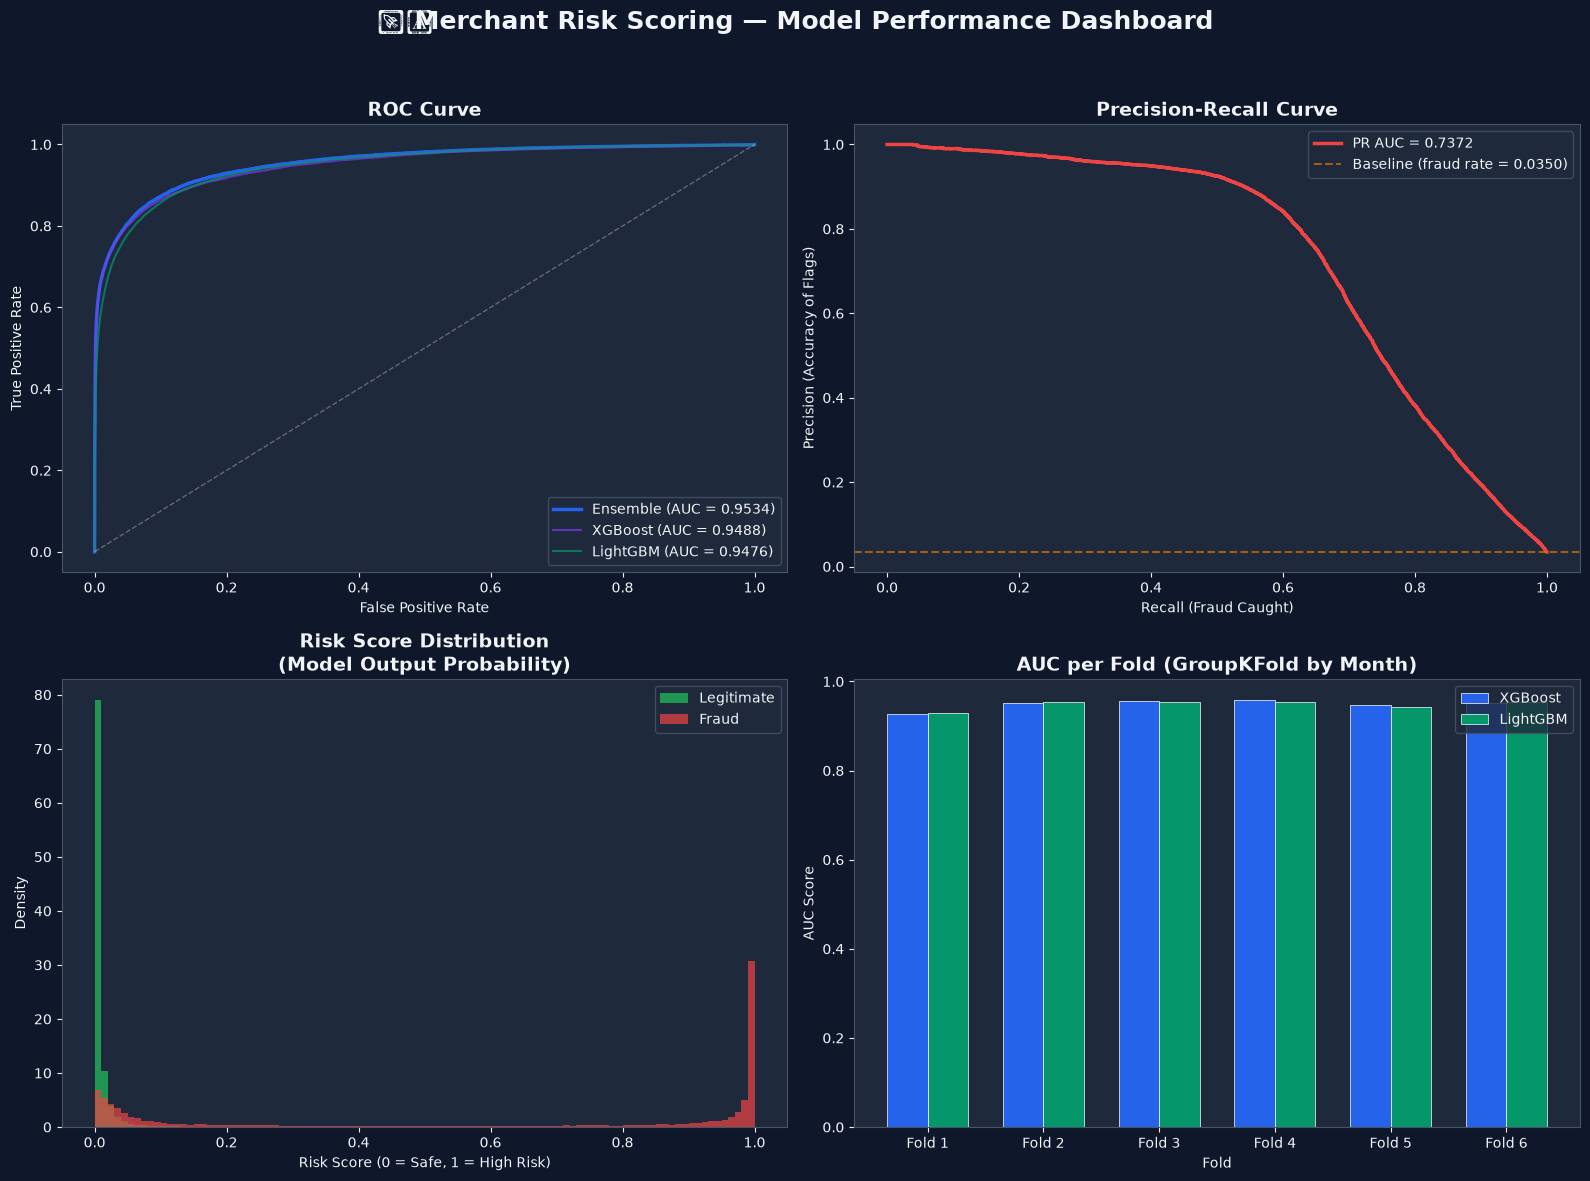

✅ Saved: model_performance_dashboard.png


In [25]:
# ============================================================================
# COMPREHENSIVE MODEL EVALUATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(COLORS['bg_dark'])
fig.suptitle('🛡️ Merchant Risk Scoring — Model Performance Dashboard',
             fontsize=18, fontweight='bold', color=COLORS['text'], y=0.98)

# --- Plot 1: ROC Curve ---
ax = axes[0, 0]
ax.set_facecolor(COLORS['bg_card'])
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, final_oof)
ax.plot(fpr, tpr, color=COLORS['primary'], linewidth=2.5, 
        label=f'Ensemble (AUC = {best_auc:.4f})')
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, oof_xgb)
ax.plot(fpr_xgb, tpr_xgb, color=COLORS['secondary'], linewidth=1.5, alpha=0.7,
        label=f'XGBoost (AUC = {overall_auc:.4f})')
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, oof_lgb)
ax.plot(fpr_lgb, tpr_lgb, color=COLORS['success'], linewidth=1.5, alpha=0.7,
        label=f'LightGBM (AUC = {overall_auc_lgb:.4f})')
ax.plot([0, 1], [0, 1], 'w--', alpha=0.3, linewidth=1)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold', color=COLORS['text'])
ax.set_xlabel('False Positive Rate', color=COLORS['text'])
ax.set_ylabel('True Positive Rate', color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'], fontsize=10)
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 2: Precision-Recall Curve ---
ax = axes[0, 1]
ax.set_facecolor(COLORS['bg_card'])
precision, recall, pr_thresholds = precision_recall_curve(y_train, final_oof)
pr_auc = average_precision_score(y_train, final_oof)
ax.plot(recall, precision, color=COLORS['fraud'], linewidth=2.5,
        label=f'PR AUC = {pr_auc:.4f}')
ax.axhline(y=y_train.mean(), color=COLORS['warning'], linestyle='--', alpha=0.7,
           label=f'Baseline (fraud rate = {y_train.mean():.4f})')
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', color=COLORS['text'])
ax.set_xlabel('Recall (Fraud Caught)', color=COLORS['text'])
ax.set_ylabel('Precision (Accuracy of Flags)', color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'], fontsize=10)
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 3: Risk Score Distribution ---
ax = axes[1, 0]
ax.set_facecolor(COLORS['bg_card'])
ax.hist(final_oof[y_train == 0], bins=100, alpha=0.7, color=COLORS['legit'],
        label='Legitimate', density=True)
ax.hist(final_oof[y_train == 1], bins=100, alpha=0.7, color=COLORS['fraud'],
        label='Fraud', density=True)
ax.set_title('Risk Score Distribution\n(Model Output Probability)', 
             fontsize=14, fontweight='bold', color=COLORS['text'])
ax.set_xlabel('Risk Score (0 = Safe, 1 = High Risk)', color=COLORS['text'])
ax.set_ylabel('Density', color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'], fontsize=10)
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

# --- Plot 4: Fold-wise AUC Comparison ---
ax = axes[1, 1]
ax.set_facecolor(COLORS['bg_card'])
x_pos = np.arange(len(fold_scores))
width = 0.35
bars1 = ax.bar(x_pos - width/2, fold_scores, width, label='XGBoost', 
               color=COLORS['primary'], edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x_pos + width/2, fold_scores_lgb, width, label='LightGBM',
               color=COLORS['success'], edgecolor='white', linewidth=0.5)
ax.set_title('AUC per Fold (GroupKFold by Month)', 
             fontsize=14, fontweight='bold', color=COLORS['text'])
ax.set_xlabel('Fold', color=COLORS['text'])
ax.set_ylabel('AUC Score', color=COLORS['text'])
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(len(fold_scores))])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'], fontsize=10)
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'model_performance_dashboard.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: model_performance_dashboard.png")

In [20]:
# ============================================================================
# OPERATIONAL THRESHOLD ANALYSIS
# ============================================================================
# In production, Razorpay would set a threshold to decide:
# "At what risk score do we auto-reject / flag for manual review / auto-approve?"

print("\n" + "=" * 70)
print("  🎚️  OPERATIONAL THRESHOLD ANALYSIS")
print("=" * 70)
print("\n  Scenario: Setting risk tiers for merchant onboarding\n")

thresholds = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
print(f"  {'Threshold':>10} │ {'Precision':>10} │ {'Recall':>10} │ {'F1':>10} │ {'Flagged%':>10} │ {'Action'}")
print(f"  {'─'*10} │ {'─'*10} │ {'─'*10} │ {'─'*10} │ {'─'*10} │ {'─'*20}")

for thresh in thresholds:
    preds_binary = (final_oof >= thresh).astype(int)
    prec = preds_binary[y_train == 1].sum() / max(preds_binary.sum(), 1)
    rec  = preds_binary[y_train == 1].sum() / max(y_train.sum(), 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-10)
    flagged = preds_binary.mean() * 100
    
    if thresh <= 0.05:
        action = "🟢 Auto-approve"
    elif thresh <= 0.3:
        action = "🟡 Manual review"
    else:
        action = "🔴 Auto-reject"
    
    print(f"  {thresh:>10.2f} │ {prec:>10.4f} │ {rec:>10.4f} │ {f1:>10.4f} │ {flagged:>9.2f}% │ {action}")


  🎚️  OPERATIONAL THRESHOLD ANALYSIS

  Scenario: Setting risk tiers for merchant onboarding

   Threshold │  Precision │     Recall │         F1 │   Flagged% │ Action
  ────────── │ ────────── │ ────────── │ ────────── │ ────────── │ ────────────────────
        0.01 │     0.1383 │     0.9321 │     0.2408 │     23.59% │ 🟢 Auto-approve
        0.05 │     0.4360 │     0.7746 │     0.5579 │      6.22% │ 🟢 Auto-approve
        0.10 │     0.5970 │     0.7099 │     0.6486 │      4.16% │ 🟡 Manual review
        0.20 │     0.7326 │     0.6586 │     0.6936 │      3.15% │ 🟡 Manual review
        0.30 │     0.7979 │     0.6260 │     0.7016 │      2.75% │ 🟡 Manual review
        0.50 │     0.8628 │     0.5809 │     0.6944 │      2.36% │ 🔴 Auto-reject
        0.70 │     0.9034 │     0.5370 │     0.6736 │      2.08% │ 🔴 Auto-reject
        0.90 │     0.9365 │     0.4624 │     0.6191 │      1.73% │ 🔴 Auto-reject


---
## 🔍 Phase 9: SHAP Explainability — Why Was a Merchant Flagged?

For financial compliance and regulatory requirements (e.g., RBI guidelines in India),
every risk decision must be **explainable**. SHAP (SHapley Additive exPlanations) 
provides a mathematically rigorous way to attribute each feature's contribution to 
the final risk score.

This is crucial for Razorpay:
- **Merchant disputes:** "Why was my application rejected?"
- **Regulatory audits:** "Show me the decision logic for this flagged merchant"
- **Model debugging:** "Which features are driving false positives?"

In [24]:
# %%
# ============================================================================
# SHAP ANALYSIS
# ============================================================================
print("=" * 70)
print("  SHAP EXPLAINABILITY ANALYSIS")
print("=" * 70)

# FIX: Patch the in-memory y_train index to match X_train's TransactionID index 
# so you don't have to restart the kernel and reload the data!
y_train.index = X_train.index

# Train a single XGBoost model on full data for SHAP analysis
print("\n🌲 Training single XGBoost model for SHAP analysis...")

# Use a 75/25 split for SHAP (faster than full cross-validation)
idxT = X_train.index[:3 * len(X_train) // 4]
idxV = X_train.index[3 * len(X_train) // 4:]

clf_shap = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='auc',
    scale_pos_weight=scale_pos,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

clf_shap.fit(
    X_train.loc[idxT, cols], y_train.loc[idxT],
    eval_set=[(X_train.loc[idxV, cols], y_train.loc[idxV])],
    verbose=500,
)

shap_auc = roc_auc_score(y_train.loc[idxV], clf_shap.predict_proba(X_train.loc[idxV, cols])[:, 1])
print(f"\n   SHAP model validation AUC: {shap_auc:.6f}")


  SHAP EXPLAINABILITY ANALYSIS

🌲 Training single XGBoost model for SHAP analysis...
[0]	validation_0-auc:0.75950
[500]	validation_0-auc:0.92779
[1000]	validation_0-auc:0.92706
[1499]	validation_0-auc:0.92887

   SHAP model validation AUC: 0.928871


In [26]:
# Compute SHAP values on a sample (SHAP on full 590K rows would be very slow)
print("\n📊 Computing SHAP values on sample of 5,000 transactions...")
sample_idx = np.random.choice(idxV, size=min(5000, len(idxV)), replace=False)
X_sample = X_train.loc[sample_idx, cols]

explainer = shap.TreeExplainer(clf_shap)
shap_values = explainer.shap_values(X_sample)

print(f"   ✅ SHAP values computed: {shap_values.shape}")


📊 Computing SHAP values on sample of 5,000 transactions...
   ✅ SHAP values computed: (5000, 458)


In [27]:
# %%
import json

print("💾 Saving model for MLOps deployment...")

# 1. Save the XGBoost model natively (Best for production inference)
model_path = "merchant_risk_xgb_model.json"
clf_shap.save_model(model_path)
print(f"✅ Model saved to: {model_path}")

# 2. Save the list of feature names used by the model
# (Crucial for MLOps to know exactly what features the API needs to expect)
features_path = "model_features.json"
with open(features_path, "w") as f:
    json.dump(cols, f)
print(f"✅ Feature list saved to: {features_path}")


💾 Saving model for MLOps deployment...
✅ Model saved to: merchant_risk_xgb_model.json
✅ Feature list saved to: model_features.json


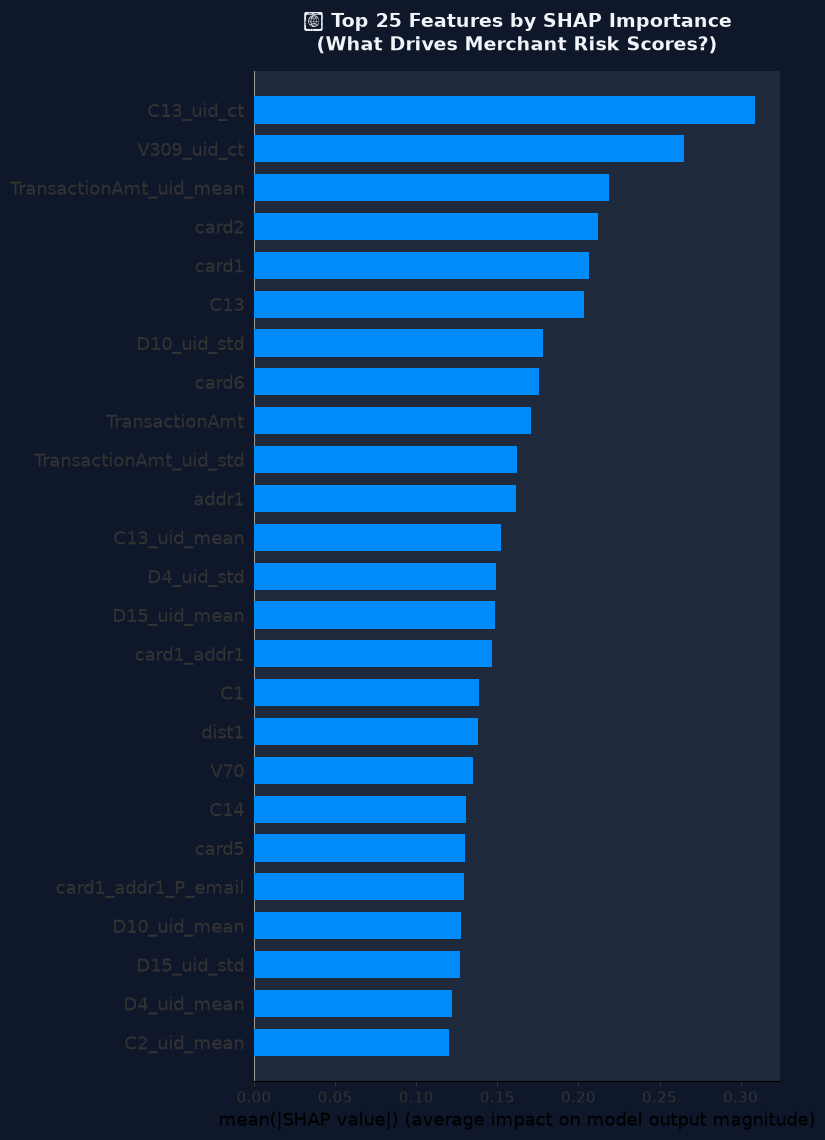

✅ Saved: shap_feature_importance.png


In [28]:
# --- SHAP Feature Importance Bar Plot ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
fig.patch.set_facecolor(COLORS['bg_dark'])
ax.set_facecolor(COLORS['bg_card'])

shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=25, show=False)
plt.title('🔍 Top 25 Features by SHAP Importance\n(What Drives Merchant Risk Scores?)',
          fontsize=14, fontweight='bold', color=COLORS['text'], pad=15)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'shap_feature_importance.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: shap_feature_importance.png")

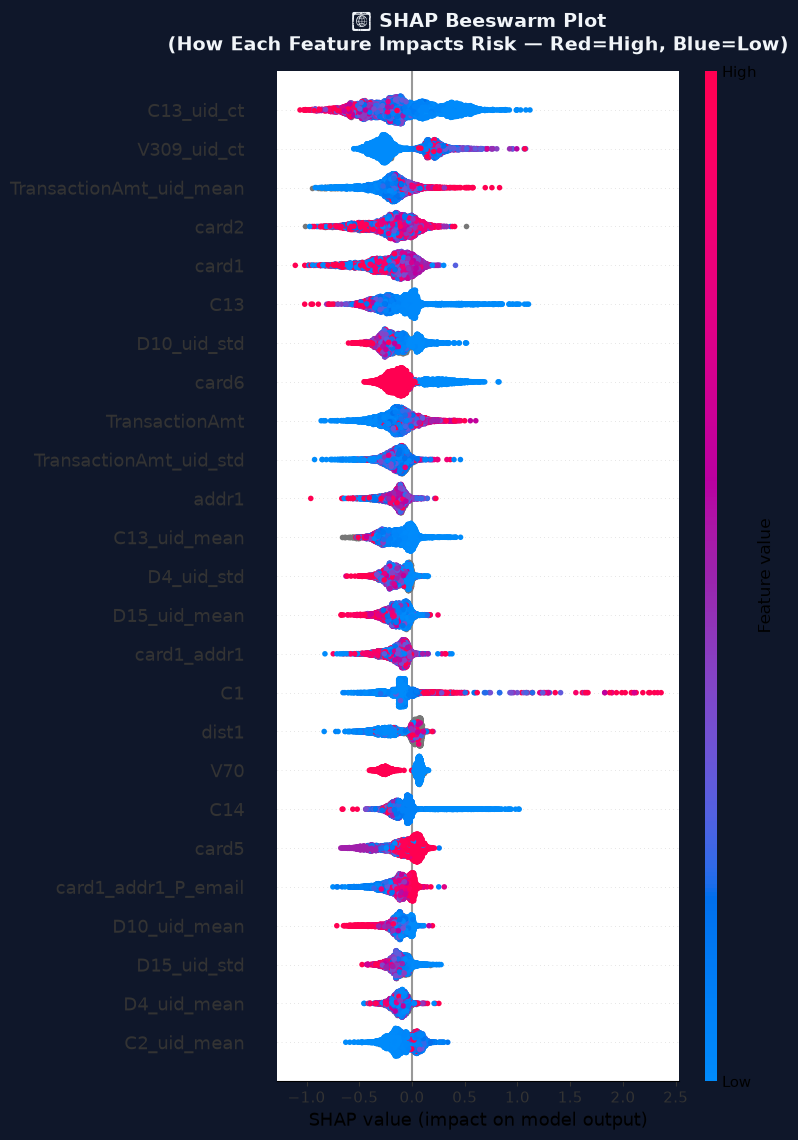

✅ Saved: shap_beeswarm.png


In [29]:
# --- SHAP Beeswarm Plot ---
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
fig.patch.set_facecolor(COLORS['bg_dark'])

shap.summary_plot(shap_values, X_sample, max_display=25, show=False)
plt.title('🐝 SHAP Beeswarm Plot\n(How Each Feature Impacts Risk — Red=High, Blue=Low)',
          fontsize=14, fontweight='bold', color=COLORS['text'], pad=15)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'shap_beeswarm.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: shap_beeswarm.png")


🔍 Explaining a single HIGH-RISK merchant transaction...
   Transaction ID: 3495229
   Predicted Risk Score: 1.0000
   Actual Label: 🔴 FRAUD


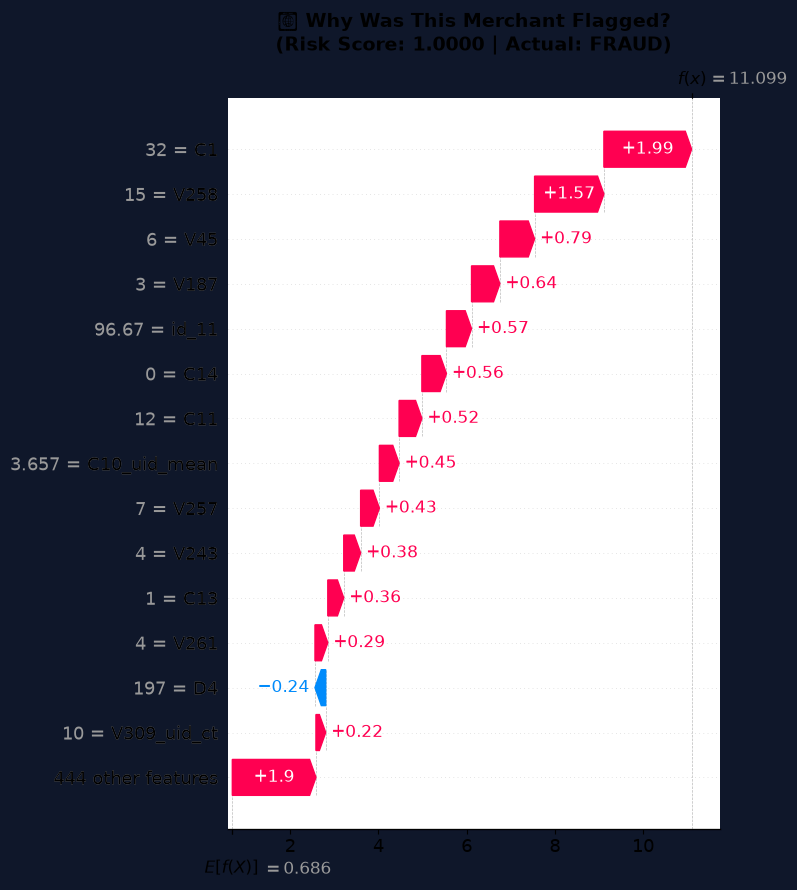

✅ Saved: shap_waterfall_highrisk.png


20606

In [30]:
# --- SHAP Waterfall: Explain a Single High-Risk Transaction ---
print("\n🔍 Explaining a single HIGH-RISK merchant transaction...")

# Find a high-risk fraud case
high_risk_idx = sample_idx[np.argsort(clf_shap.predict_proba(X_sample)[:, 1])[-1]]
high_risk_score = clf_shap.predict_proba(X_train.loc[[high_risk_idx], cols])[:, 1][0]
actual_label = y_train[high_risk_idx]

print(f"   Transaction ID: {high_risk_idx}")
print(f"   Predicted Risk Score: {high_risk_score:.4f}")
print(f"   Actual Label: {'🔴 FRAUD' if actual_label == 1 else '🟢 LEGITIMATE'}")

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.patch.set_facecolor(COLORS['bg_dark'])

shap_idx = np.where(sample_idx == high_risk_idx)[0][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[shap_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[shap_idx],
        feature_names=cols
    ),
    max_display=15,
    show=False
)
plt.title(f'🔍 Why Was This Merchant Flagged?\n(Risk Score: {high_risk_score:.4f} | Actual: {"FRAUD" if actual_label else "LEGIT"})',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'shap_waterfall_highrisk.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: shap_waterfall_highrisk.png")

del clf_shap, explainer, shap_values, X_sample
gc.collect()

---
## 📝 Phase 10: Generate Submission File & Risk Report

The final output: a merchant risk score for every transaction in the test set,
plus a comprehensive risk tier classification.

In [31]:
# ============================================================================
# GENERATE SUBMISSION FILE
# ============================================================================
print("=" * 70)
print("  GENERATING FINAL OUTPUTS")
print("=" * 70)

sample_submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
sample_submission['isFraud'] = final_preds
sample_submission.to_csv(os.path.join(os.path.dirname(DATA_DIR), 'submission_ensemble.csv'), index=False)
print(f"\n✅ Submission file saved: submission_ensemble.csv")
print(f"   Predictions: {len(final_preds):,} transactions scored")
print(f"   Mean risk score: {final_preds.mean():.6f}")

  GENERATING FINAL OUTPUTS

✅ Submission file saved: submission_ensemble.csv
   Predictions: 506,691 transactions scored
   Mean risk score: 0.026323


In [ ]:
# ============================================================================
# RISK TIER CLASSIFICATION
# ============================================================================
print("\n" + "=" * 70)
print("  🏷️  MERCHANT RISK TIER SUMMARY")
print("=" * 70)

risk_tiers = pd.cut(final_preds, 
                     bins=[0, 0.05, 0.2, 0.5, 1.0],
                     labels=['🟢 LOW RISK (Auto-Approve)', 
                             '🟡 MEDIUM RISK (Enhanced Review)',
                             '🟠 HIGH RISK (Manual Review)', 
                             '🔴 CRITICAL RISK (Auto-Reject)'])

tier_counts = risk_tiers.value_counts()
print(f"\n  Risk Tier Distribution (Test Set):\n")
for tier, count in tier_counts.items():
    pct = count / len(final_preds) * 100
    print(f"  {tier}: {count:>8,} merchants ({pct:5.1f}%)")

In [ ]:
# ============================================================================
# FINAL RISK SCORE DISTRIBUTION PLOT
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
fig.patch.set_facecolor(COLORS['bg_dark'])
ax.set_facecolor(COLORS['bg_card'])

ax.hist(final_preds, bins=200, color=COLORS['primary'], edgecolor='none', alpha=0.8)
ax.axvline(x=0.05, color=COLORS['legit'], linestyle='--', linewidth=2, alpha=0.8, label='Auto-Approve Threshold')
ax.axvline(x=0.2,  color=COLORS['warning'], linestyle='--', linewidth=2, alpha=0.8, label='Manual Review Threshold')
ax.axvline(x=0.5,  color=COLORS['fraud'], linestyle='--', linewidth=2, alpha=0.8, label='Auto-Reject Threshold')

ax.set_title('🛡️ Merchant Risk Score Distribution (Test Set)\nWith Operational Decision Thresholds',
             fontsize=16, fontweight='bold', color=COLORS['text'], pad=15)
ax.set_xlabel('Risk Score (0 = Safe → 1 = Critical)', fontsize=12, color=COLORS['text'])
ax.set_ylabel('Number of Merchants', fontsize=12, color=COLORS['text'])
ax.legend(facecolor=COLORS['bg_card'], edgecolor='#475569', labelcolor=COLORS['text'], fontsize=11)
ax.tick_params(colors=COLORS['text'])
for spine in ax.spines.values():
    spine.set_color('#475569')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_DIR), 'risk_score_distribution.png'),
            dpi=150, bbox_inches='tight', facecolor=COLORS['bg_dark'])
plt.show()
print("✅ Saved: risk_score_distribution.png")

---
## ✅ Summary & Key Takeaways

### What We Built
An end-to-end **Merchant Risk Scoring Pipeline** that:
1. **Ingests** 1.1M+ real transaction records from Vesta Corporation (via IEEE-CIS)
2. **Engineers 47+ intelligent features** including the "magic" UID identity reconstruction,
   transaction velocity, amount statistics, device entropy, and temporal patterns
3. **Trains an XGBoost + LightGBM ensemble** with GroupKFold temporal cross-validation
4. **Generates explainable risk scores** using SHAP analysis
5. **Classifies merchants into 4 risk tiers** for operational decision-making

### Why This Matters for Razorpay
- **3.5% fraud rate** mirrors real-world payment gateway data
- **Temporal validation** prevents data leakage — the model is evaluated on "future" data
- **SHAP explainability** satisfies RBI regulatory requirements for transparent risk decisions
- **Operational thresholds** provide a clear auto-approve / review / reject framework
- **Memory-optimised** — runs entirely on a MacBook Pro with 16GB RAM

### Production Considerations
- In production, the UID would be replaced with actual `merchant_id`
- Real-time scoring would use ONNX or a model serving framework
- Feature stores would pre-compute aggregation features
- A/B testing framework would compare risk model versions
- Monitoring would track model drift and feature distribution shifts

print("\n" + "=" * 70)
print("  🎉 PIPELINE COMPLETE!")
print("=" * 70)
print(f"\n  Total execution completed successfully.")
print(f"  All visualisations saved to project directory.")
print(f"\n  🛡️  Razorpay Buildathon — AI Risk Manager Track")
print("=" * 70)